In [73]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
data = pd.read_csv('https://raw.githubusercontent.com/kdemertzis/EKPA/refs/heads/main/Data/phishing_dataset.csv', delimiter=',')

In [74]:
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,olx.pl,0,0,1,7,0,0,0,0,0,1,1,1,0,0,1,0,0
1,nypost.com,0,0,1,4,0,0,1,0,0,1,0,0,0,0,1,0,0
2,twitter.com,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
3,u718633rwt.ha004.t.justns.ru,0,0,0,3,0,0,0,0,0,0,0,0,0,0,1,0,1
4,dantri.com.vn,0,0,1,2,0,0,0,0,1,1,1,1,0,0,1,0,0


In [75]:
X = data.drop(['Domain', 'Label'], axis=1)
Y = y=np.ravel(data['Label'])

In [76]:
X.head()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards
0,0,0,1,7,0,0,0,0,0,1,1,1,0,0,1,0
1,0,0,1,4,0,0,1,0,0,1,0,0,0,0,1,0
2,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0
3,0,0,0,3,0,0,0,0,0,0,0,0,0,0,1,0
4,0,0,1,2,0,0,0,0,1,1,1,1,0,0,1,0


In [77]:
data.shape

(10000, 18)

In [78]:
data.columns

Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record',
       'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over',
       'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

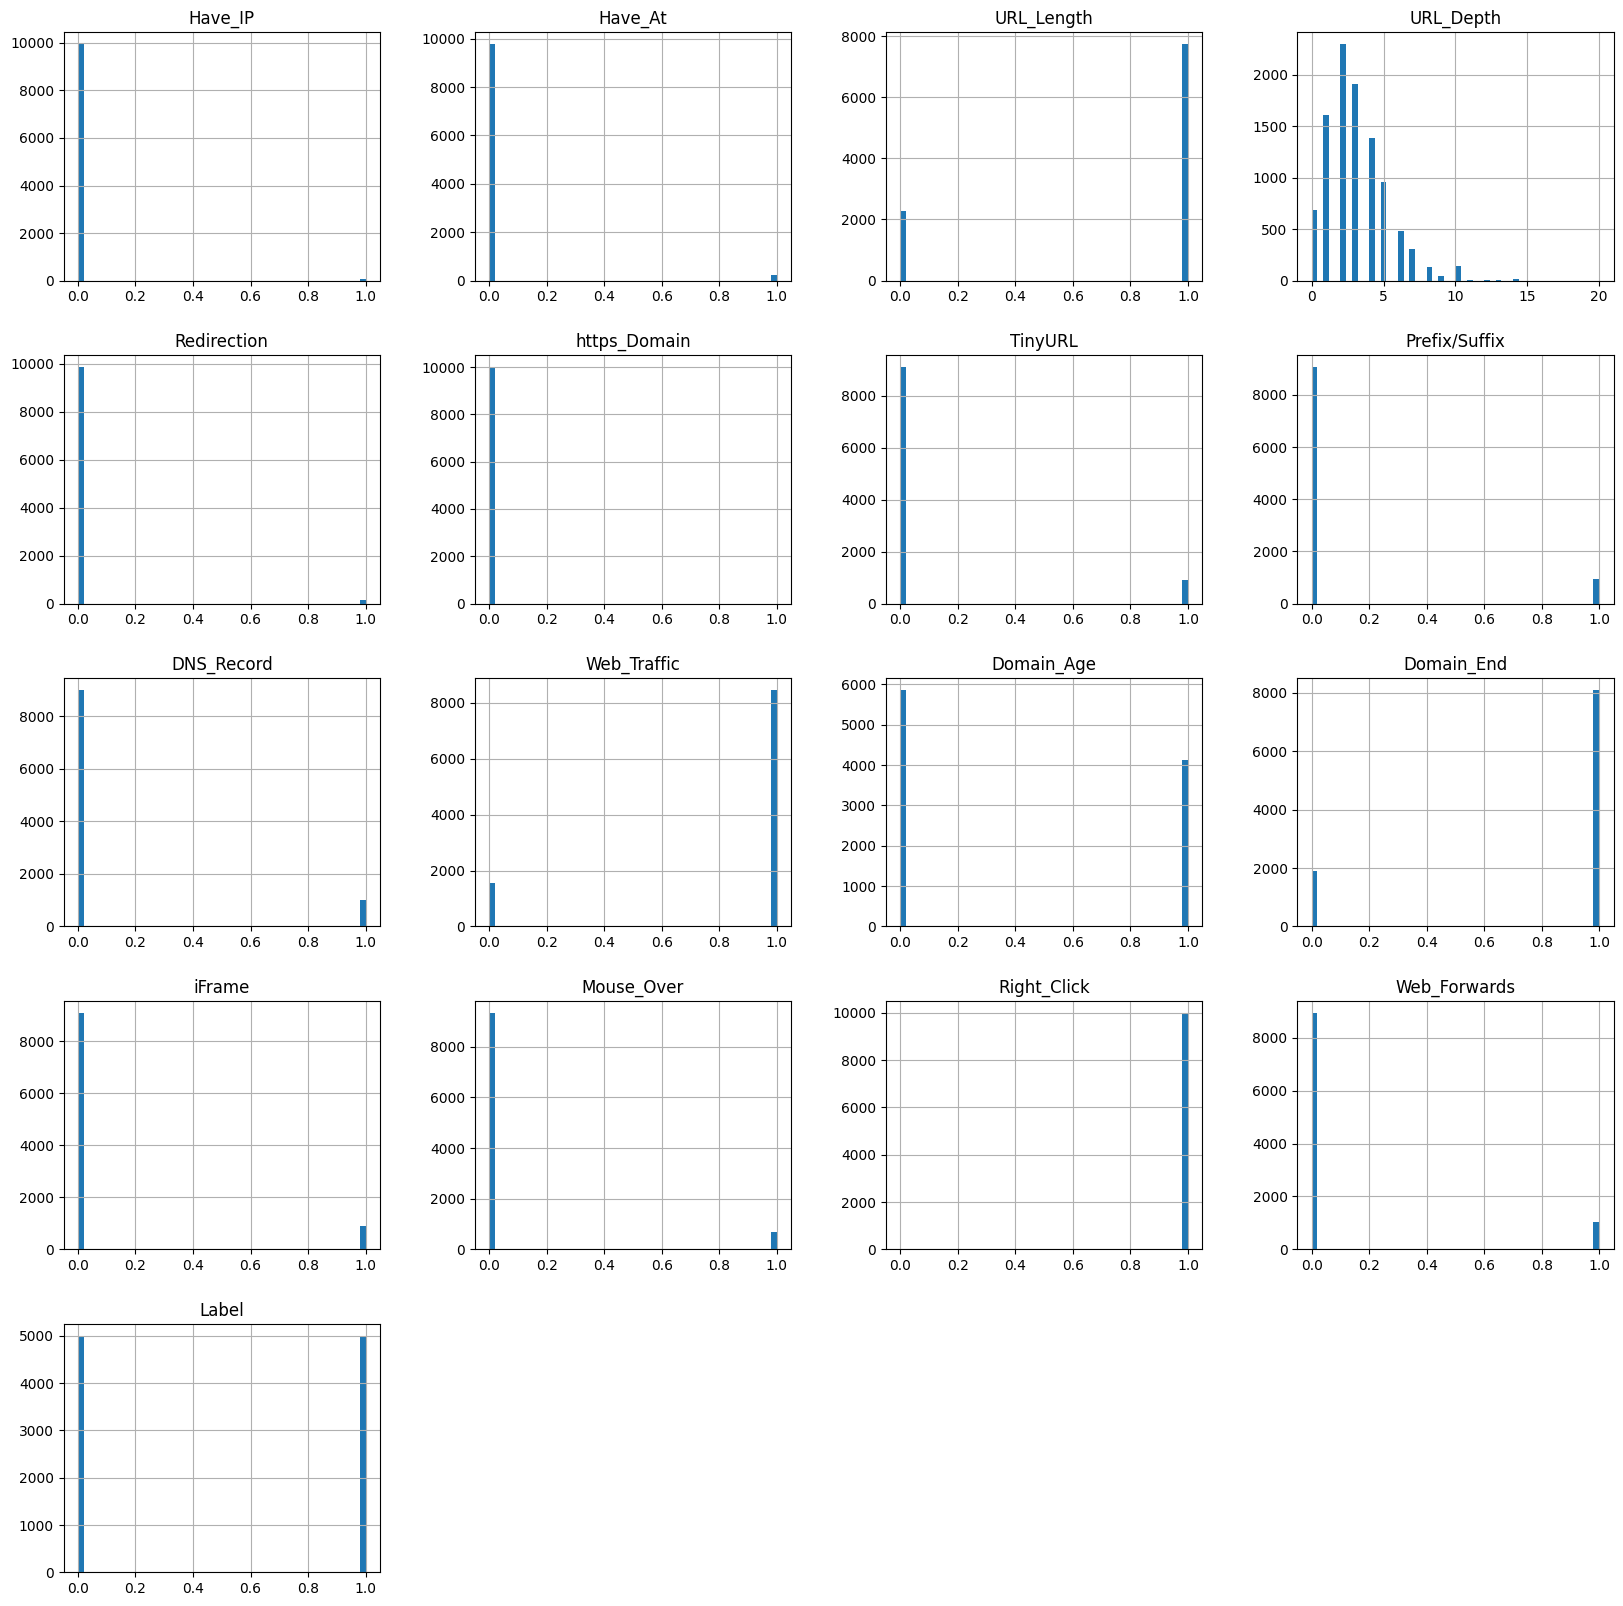

In [81]:
import matplotlib.pyplot as plt
data.hist(bins = 50,figsize = (20,20))
plt.show()

In [82]:
data.describe()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000
mean,0.005500,0.022600,0.773400,3.072000,0.013500,0.000200,0.090300,0.093200,0.100800,0.845700,0.413700,0.8099,0.090900,0.06660,0.99930,0.105300,0.500000
std,0.073961,0.148632,0.418653,2.128631,0.115408,0.014141,0.286625,0.290727,0.301079,0.361254,0.492521,0.3924,0.287481,0.24934,0.02645,0.306955,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.500000
75%,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0000,0.000000,0.00000,1.00000,0.000000,1.000000
max,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.00000,1.00000,1.000000,1.000000


In [83]:
data.isnull().sum()

,0
Domain,0
Have_IP,0
Have_At,0
URL_Length,0
URL_Depth,0
Redirection,0
https_Domain,0
TinyURL,0
Prefix/Suffix,0
DNS_Record,0


In [84]:
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,hubpages.com,0,0,1,2,0,0,0,0,0,1,0,1,0,0,1,0,0
1,caixa.gov.br,0,0,1,6,0,0,0,0,0,1,1,1,0,0,1,1,0
2,udn.com,0,0,1,4,0,0,0,0,0,1,0,1,0,0,1,0,0
3,thenextweb.com,0,0,1,6,0,0,0,0,0,1,0,0,0,0,1,0,0
4,mmagaluofertashoje.com,0,0,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1


In [85]:
y = data['Label']
X = data.drop(['Domain', 'Label'], axis=1)
X.shape, y.shape

((10000, 16), (10000,))

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, random_state = 12)
X_train.shape, X_test.shape

((8000, 16), (2000, 16))

In [87]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
classifiers = [
    LogisticRegression(),
    SVC(),
    RandomForestClassifier(),
    MLPClassifier(),
    KNeighborsClassifier(),
    DecisionTreeClassifier()
]

In [89]:
results = {'Classifier': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}


In [90]:
for clf in classifiers:
    clf_name = clf.__class__.__name__
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results['Classifier'].append(clf_name)
    results['Accuracy'].append(acc)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

    print(f"\n{clf_name} Results:")
    print(f"Accuracy: {acc}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")


LogisticRegression Results:
Accuracy: 0.797
Precision: 0.9234972677595629
Recall: 0.6588693957115009
F1 Score: 0.7690557451649602

SVC Results:
Accuracy: 0.827
Precision: 0.9722222222222222
Recall: 0.682261208576998
F1 Score: 0.8018327605956472

RandomForestClassifier Results:
Accuracy: 0.854
Precision: 0.9228110599078341
Recall: 0.7807017543859649
F1 Score: 0.8458289334741288

MLPClassifier Results:
Accuracy: 0.8455
Precision: 0.8961325966850828
Recall: 0.7904483430799221
F1 Score: 0.8399792853443812

KNeighborsClassifier Results:
Accuracy: 0.844
Precision: 0.925
Recall: 0.7573099415204678
F1 Score: 0.8327974276527331

DecisionTreeClassifier Results:
Accuracy: 0.854
Precision: 0.9247685185185185
Recall: 0.7787524366471735
F1 Score: 0.8455026455026455


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [91]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print("\nComparison of Classifiers:")
print(results_df)


Comparison of Classifiers:
               Classifier  Accuracy  Precision    Recall  F1 Score
5  DecisionTreeClassifier    0.8540   0.924769  0.778752  0.845503
2  RandomForestClassifier    0.8540   0.922811  0.780702  0.845829
3           MLPClassifier    0.8455   0.896133  0.790448  0.839979
4    KNeighborsClassifier    0.8440   0.925000  0.757310  0.832797
1                     SVC    0.8270   0.972222  0.682261  0.801833
0      LogisticRegression    0.7970   0.923497  0.658869  0.769056


###Συμπερασματικά το Random Forest είναι το πιο κατάλληλο μοντέλο καθώς έχει καλύτερη ισορροπία μετσξύ Precision και Recall με υψηλότερο το F1 Score